# 02 — Feature Matrix
Daily features shared by entry filters and ML models: VIX rank, RSI, realized
vol, vol-risk premium, trend. Everything is computed from close-of-day data —
no lookahead.

### Daily feature matrix
VIX rank, RSI(14), realized vol, VRP, trend. Same features for backtests + ML.


In [1]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 160)

### Implied vs realized vol
VIX vs RV: when VIX > RV, vol-risk premium is positive (short vol attractive).


In [2]:
from lab.market_data import load_market
from lab.features import build_features, ML_FEATURES

feats = build_features(load_market())
feats.tail()

,quote_date,spx_close,vix,vix_rank,vix_chg_5d,rsi14,realized_vol_20d,vol_risk_premium,ret_5d,ret_21d,sma50_above_sma200,dist_from_high_52w,day_of_week
4396,2026-06-26,7354.020020,18.410000,0.682540,0.122561,46.073616,16.939376,1.470624,-0.019540,-0.022119,1,-0.033609,4
4397,2026-06-29,7440.430176,17.650000,0.599206,0.021412,52.276144,17.531749,0.118251,-0.004330,-0.016288,1,-0.022254,0
4398,2026-06-30,7499.359863,16.450001,0.369048,-0.155977,55.993532,17.771321,-1.321321,0.018179,-0.010646,1,-0.014510,1
4399,2026-07-01,7483.229980,16.590000,0.396825,-0.109501,54.736741,17.763057,-1.173057,0.016989,-0.015359,1,-0.016630,2
4400,2026-07-02,7483.240234,16.150000,0.281746,-0.145050,54.737437,17.593959,-1.443960,0.017091,-0.016629,1,-0.016629,3


### Regime detection
RSI < 30 = oversold. VIX rank = where vol sits in past year. Co-movement shows clustering.


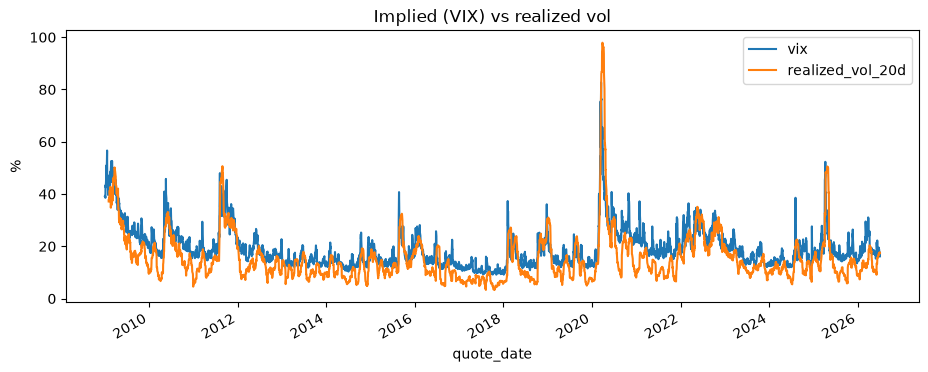

In [3]:
ax = feats.set_index("quote_date")[["vix", "realized_vol_20d"]].plot(title="Implied (VIX) vs realized vol")
ax.set_ylabel("%");

### Filter prevalence
Too-rare filters = noisy. Too-common = no selectivity.


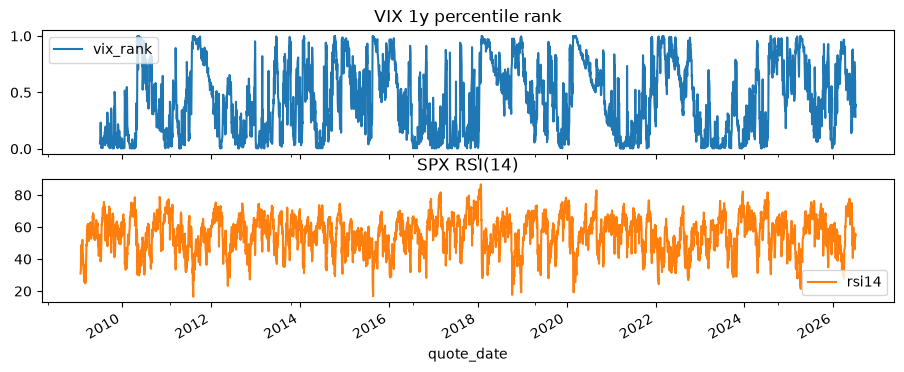

In [4]:
feats.set_index("quote_date")[["vix_rank", "rsi14"]].plot(subplots=True, title=["VIX 1y percentile rank", "SPX RSI(14)"]);

## Regime scatter: where do high-vol / oversold days live?

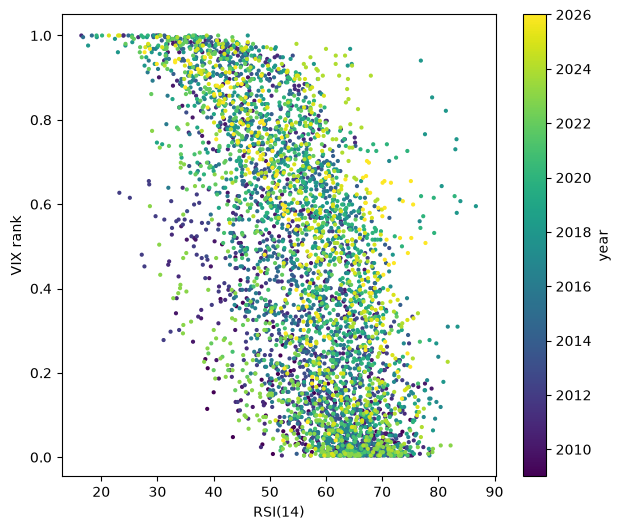

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(feats.rsi14, feats.vix_rank, c=feats.quote_date.dt.year, s=4, cmap="viridis")
ax.set_xlabel("RSI(14)"); ax.set_ylabel("VIX rank"); plt.colorbar(sc, label="year");

In [6]:
# How often is each candidate entry filter true?
for expr in ["vix_rank > 0.5", "vix_rank > 0.8", "rsi14 < 30", "vix_rank > 0.5 and rsi14 < 40"]:
    print(f"{expr:40s} {feats.eval(expr).mean():6.1%} of days")

vix_rank > 0.5                            42.2% of days
vix_rank > 0.8                            17.2% of days
rsi14 < 30                                 1.6% of days
vix_rank > 0.5 and rsi14 < 40              8.6% of days
